In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from itertools import combinations
import sympy as sp

from ortools.linear_solver import pywraplp
from IPython.display import display, Markdown

def md(title, body):
    """
    계산 결과를 Markdown 형식으로 출력하는 보조함수.

    title : 해석 블록의 제목
    body  : 분석 결과에 대한 자연어 설명
    """
    
    display(
        Markdown(
            f"### {title}\n\n{body}"
        )
    )

STATUS_LABEL = {
    pywraplp.Solver.OPTIMAL: "OPTIMAL",
    pywraplp.Solver.FEASIBLE: "FEASIBLE",
    pywraplp.Solver.INFEASIBLE: "INFEASIBLE",
    pywraplp.Solver.UNBOUNDED: "UNBOUNDED",
    pywraplp.Solver.NOT_SOLVED: "NOT_SOLVED",
}


md(
    "환경 설정 완료",
    "이제부터 모든 결과를 **수식 → Solver → DataFrame → 자연어 해석** 순서로 확인한다."
)


plt.rcParams["axes.unicode_minus"] = False

HUMAN_CAP = 80
TOKEN_CAP = 100
PROFIT_TARGET = 210

print("STEP3 환경설정 완료")

### 환경 설정 완료

이제부터 모든 결과를 **수식 → Solver → DataFrame → 자연어 해석** 순서로 확인한다.

STEP3 환경설정 완료


# STEP 3 — Free Variable, Rank, Dimension

"자유변수"라는 말을 섞으면 안 된다.

서로 다른 세 개의 개념을 구별한다.

---

## A. Linear Algebra Free Variable

RREF에서 Pivot이 없는 Column의 변수.

이 변수는 Solution Set의 자유도를 만든다.

---

## B. LP Unrestricted Variable

부호 제한이 없는 변수.

$$
u\in\mathbb R
$$

Simplex Standard Form에서는 보통

$$
u=u^+-u^-
$$

로 바꾼다.

---

## C. Simplex Nonbasic Variable

현재 Basis에 포함되지 않은 변수.

Basic Solution을 계산할 때

$$
x_N=0
$$

으로 둔다.

---

이 세 개는 이름이나 모양이 비슷하지만
완전히 다른 개념이다.

# 3-1. RREF에서의 Free Variable

P0, P1, P2 세 상품만 생각하자.

변수를

$$
x=
\begin{bmatrix}
x_0\\
x_1\\
x_2
\end{bmatrix}
$$

라고 하자.

다음 두 조건을 정확히 만족한다고 하자.

Profit:

$$
20x_0+30x_1+40x_2=120
$$

Human Time:

$$
6x_0+12x_1+14x_2=44
$$

Matrix Form:

$$
Ax=b
$$

$$
A=
\begin{bmatrix}
20&30&40\\
6&12&14
\end{bmatrix}
$$

이다.

미지수는 3개인데 독립방정식은 2개다.

따라서 하나의 자유도가 남을 가능성이 있다.

In [4]:
A_free = sp.Matrix(
    [
        [20, 30, 40],
        [6, 12, 14],
    ]
)

b_free = sp.Matrix(
    [
        120,
        44,
    ]
)

augmented = A_free.row_join(
    b_free
)
# [A|B] augmented Matrix를 만든다.

rref_matrix, pivot_columns = (
    augmented.rref()
) # reduced row ecelon form을 구한다.

print("Augmented Matrix :")
display(augmented)

print("RREF : ")
display(rref_matrix)

print("Pivot columns = ", pivot_columns)



Augmented Matrix :


Matrix([
[20, 30, 40, 120],
[ 6, 12, 14,  44]])

RREF : 


Matrix([
[1, 0,   1,   2],
[0, 1, 2/3, 8/3]])

Pivot columns =  (0, 1)


In [7]:
# parametrix solutiond을 코드로 확인한다.
# free_variable을 parameter_t로 둔다면, 

x0_sym, x1_sym, x2_sym = sp.symbols(
    "x0 x1 x2"
) 

solution_set = sp.linsolve(
    [
        sp.Eq(
            20*x0_sym
            + 30*x1_sym
            + 40*x2_sym,
            120,

        ),
        sp.Eq(
            6*x0_sym
            + 12*x1_sym
            + 14*x2_sym,
            44,
        ),

    ],
    (
        x0_sym,
        x1_sym,
        x2_sym,
    ),
)

display(solution_set)

{(2 - x2, 8/3 - 2*x2/3, x2)}

결과:
$$
x_0=2-x_2
$$
$$
x_1=\frac83-\frac23x_2
$$
이다.
이제:
$$
x_2=t
$$
라고 놓으면:
$$
\boxed{
x=
\begin{bmatrix}
2\\
8/3\\
0
\end{bmatrix}
+
t
\begin{bmatrix}
-1\\
-2/3\\
1
\end{bmatrix}
}
$$
이다.
이게 진짜 free variable의 의미다.

# Free Variable의 기하학적 의미

해를

$$
x=p+td
$$

로 쓸 수 있다.

여기서

$$
p=
\begin{bmatrix}
2\\
8/3\\
0
\end{bmatrix}
$$

는 Particular Solution이고,

$$
d=
\begin{bmatrix}
-1\\
-2/3\\
1
\end{bmatrix}
$$

는 Null-Space Direction이다.

왜냐하면

$$
Ap=b
$$

이고

$$
Ad=0
$$

이기 때문이다.

따라서

$$
A(p+td)
=
Ap+tAd
=
b+t0
=
b
$$

이다.

즉 d 방향으로 아무리 움직여도
원래 두 방정식의 결과는 변하지 않는다.

In [8]:
# Particular Solution과 Null Direction 검증

A_np = np.array(
    [
        [20, 30, 40],
        [6, 12, 14],
    ],
    dtype=float,
)

b_np = np.array(
    [
        120, 
        44,
    ],
    dtype=float,
)

p = np.array( #particular solution
    [
        2,
        8/3,
        0,
    ],
    dtype=float,
)

d = np.array(
    [
        -1,
        -2/3,
        1,
    ],
    dtype=float,
)
# null - space direction

print("A @ p =")
print(A_np @ p)

print("\nTarget b =")
print(b_np)

print("\nA @ d =")
print(A_np @ d)



A @ p =
[120.  44.]

Target b =
[120.  44.]

A @ d =
[0. 0.]


In [10]:
# Free Variable을 움직여 실제 해들을 만든다
# t를 바꾸면서 해가 어떻게 변하는지 확인.

t_values = np.linspace( 
    0,
    2,
    9,
) # non-nagetive 영역을 보기 위해 이번에는 t=0~2만 사용한다.

solution_rows = []

for t in t_values:
    x = p + t * d # x=p+td

    output = A_np @ x # 정말 항상 b가 나오는지.

    solution_rows.append(
        {
            "t": t,

            "x0_P0": x[0],
            "x1_P1": x[1],
            "x2_p2": x[2],

            "Profit": output[0],
            "Human": output[1],
        }
    )

free_solution_df = pd.DataFrame(
    solution_rows
)

display(free_solution_df)

print(md("여기서 *t*가 바뀌면서 프로젝트 조합은 계속 바뀐다. 그런데, $$ Profit = 120 $$ $$ Human = 44 $$ 는 계속 같다."," 즉 d는 두 측정량 모두에 보이지 않는 방향이다."))

,t,x0_P0,x1_P1,x2_p2,Profit,Human
0,0.00,2.00,2.666667,0.00,120.0,44.0
1,0.25,1.75,2.500000,0.25,120.0,44.0
2,0.50,1.50,2.333333,0.50,120.0,44.0
3,0.75,1.25,2.166667,0.75,120.0,44.0
4,1.00,1.00,2.000000,1.00,120.0,44.0
5,1.25,0.75,1.833333,1.25,120.0,44.0
6,1.50,0.50,1.666667,1.50,120.0,44.0
7,1.75,0.25,1.500000,1.75,120.0,44.0
8,2.00,0.00,1.333333,2.00,120.0,44.0


### 여기서 *t*가 바뀌면서 프로젝트 조합은 계속 바뀐다. 그런데, $$ Profit = 120 $$ $$ Human = 44 $$ 는 계속 같다.

 즉 d는 두 측정량 모두에 보이지 않는 방향이다.

None


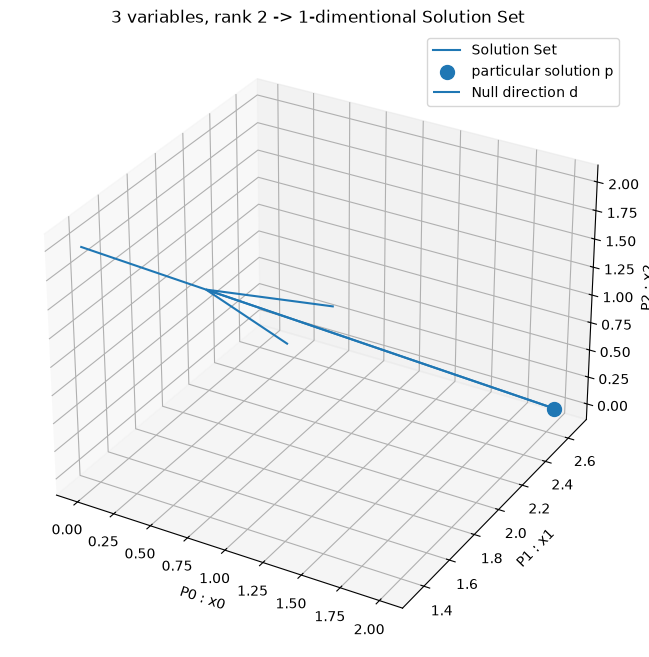

### 이제 “free variable 하나”가 왜 직선 하나를 만드는지 눈으로 보인다.



None


In [12]:
# FreeVariable이 만드는 1차원 Solution Set

t_dense = np.linspace(
    0,
    2,
    200,
)

solution_line = np.array(
    [
        p + t*d
        for t in t_dense
    ]
)

fig = plt.figure(
    figsize=(9, 8)

)

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.plot( # Solution line
    solution_line[:, 0],
    solution_line[:, 1],
    solution_line[:, 2],
    label="Solution Set"
)

ax.scatter( # particular solution.
    p[0], 
    p[1],
    p[2],
    s=100,
    label="particular solution p"
)

#p에서 null direction d를 그린다면,
ax.quiver(
    p[0],
    p[1],
    p[2],

    d[0],
    d[1],
    d[2],

    length=1.5,
    normalize=False,
    label="Null direction d",
)

ax.set_xlabel("P0 : x0")
ax.set_ylabel("P1 : x1")
ax.set_zlabel("P2 : x2")

ax.set_title(
    "3 variables, rank 2 -> 1-dimentional Solution Set"

)

ax.legend()
plt.show()

print(md("이제 “free variable 하나”가 왜 직선 하나를 만드는지 눈으로 보인다.", ""))

# 3-2. Dimension을 네 종류로 분리

"차원" 역시 하나의 뜻만 갖지 않는다.

---

## 1. Ambient Dimension

변수가 3개이므로

$$
x\in\mathbb R^3
$$

이다.

주변 전체 공간의 차원은 3.

---

## 2. Rank

현재 Matrix A의 독립적인 row/column 방향 수.

$$
rank(A)=2
$$

---

## 3. Nullity

변수 수 n에서 rank를 뺀 값.

$$
nullity(A)
=
n-rank(A)
$$

따라서

$$
3-2=1
$$

---

## 4. Solution Set Dimension

해집합은

$$
p+t d
$$

라는 하나의 parameter t로 움직인다.

따라서 해집합은 1차원이다.

---

## NumPy ndim은 또 다른 이야기

예를 들어

```python
x.shape == (3,)
x.ndim == 1
```

일 수 있다.
이것은 "수학적으로 1차원 벡터"라는 뜻이 아니다.
숫자 3개를 가진 수학적 벡터는
$$
\mathbb R^3
$$
의 벡터다.
NumPy의 ndim=1은
메모리 배열의 axis가 하나라는 뜻이다.


이 구별은 기존 선형대수 Source에서도 직접 강조했던 부분이다. 96차원 vector가 NumPy에서는 `(96,)`인 1축 array일 수 있다.



In [13]:
# [CELL 44] 서로 다른 Dimension 개념 비교


rank_A = np.linalg.matrix_rank(
    A_np
)


n_variables = A_np.shape[1]


nullity_A = (
    n_variables
    - rank_A
)


example_vector = np.array(
    [2.0, 1.0, 0.5]
)


dimension_table = pd.DataFrame(
    [
        {
            "Concept": "Ambient dimension",
            "Value": 3,
            "Meaning": "x lives in R^3",
        },
        
        {
            "Concept": "Matrix rank",
            "Value": rank_A,
            "Meaning": "independent directions constrained by A",
        },
        
        {
            "Concept": "Nullity",
            "Value": nullity_A,
            "Meaning": "free directions satisfying A d = 0",
        },
        
        {
            "Concept": "Solution-set dimension",
            "Value": nullity_A,
            "Meaning": "number of free parameters",
        },
        
        {
            "Concept": "NumPy ndim",
            "Value": example_vector.ndim,
            "Meaning": "number of array axes",
        },
    ]
)


display(dimension_table)


print("Vector shape =", example_vector.shape)

,Concept,Value,Meaning
0,Ambient dimension,3,x lives in R^3
1,Matrix rank,2,independent directions constrained by A
2,Nullity,1,free directions satisfying A d = 0
3,Solution-set dimension,1,number of free parameters
4,NumPy ndim,1,number of array axes


Vector shape = (3,)


# 3-3. LP의 Unrestricted Variable

이번에는 완전히 다른 뜻의 "자유"다.

어떤 변수 u가

$$
u\in\mathbb R
$$

이라면

$$
u=-3
$$

도 가능하고

$$
u=5
$$

도 가능하다.

즉 부호제약이 없다.

Simplex Standard Form에서는 모든 변수를

$$
x\ge0
$$

형태로 다루고 싶기 때문에

$$
\boxed{
u=u^+-u^-
}
$$

로 분해한다.

여기서

$$
u^+,u^-\ge0
$$

이다.

이것은 RREF에서의 Free Variable과 전혀 다른 개념이다.

,u_plus,u_minus,u_plus - u_minus
0,0.0,3.0,-3.0
1,1.0,4.0,-3.0
2,2.0,5.0,-3.0
3,3.0,6.0,-3.0
4,4.0,7.0,-3.0
5,5.0,8.0,-3.0


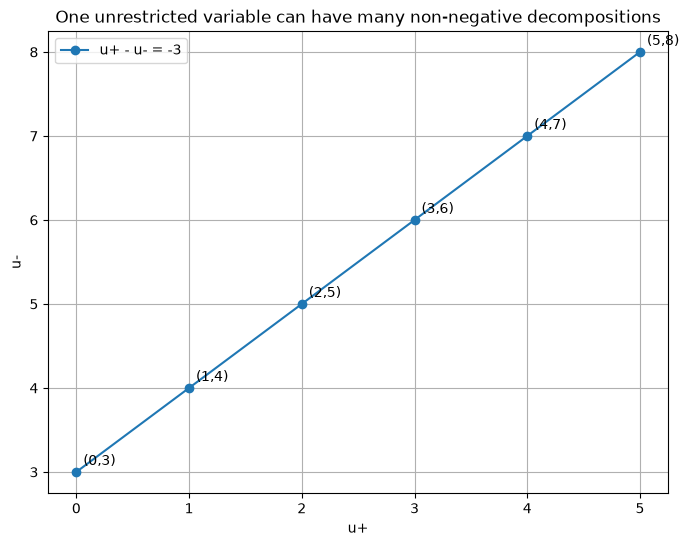

In [15]:
# [CELL 46] Unrestricted variable 분해의 비유일성


u_target = -3


u_plus_values = np.arange(
    0,
    6,
    dtype=float,
)


u_minus_values = (
    u_plus_values
    - u_target
)
# u = u+ - u-
#
# -3 = u+ - u-
#
# 따라서
# u- = u+ + 3


unrestricted_df = pd.DataFrame(
    {
        "u_plus": u_plus_values,
        "u_minus": u_minus_values,
    }
)


unrestricted_df["u_plus - u_minus"] = (
    unrestricted_df["u_plus"]
    - unrestricted_df["u_minus"]
)


display(unrestricted_df)

# [CELL 47] u+와 u-의 가능한 조합


plt.figure(figsize=(8, 6))


plt.plot(
    u_plus_values,
    u_minus_values,
    marker="o",
    label="u+ - u- = -3"
)


for up, um in zip(
    u_plus_values,
    u_minus_values,
):
    
    plt.annotate(
        f"({up:.0f},{um:.0f})",
        (up, um),
        xytext=(5, 5),
        textcoords="offset points",
    )


plt.xlabel("u+")
plt.ylabel("u-")

plt.title(
    "One unrestricted variable can have many non-negative decompositions"
)

plt.grid(True)
plt.legend()
plt.show()

# 3-4. Simplex의 Nonbasic Variable

Basis가

$$
B=\{x,s_H,s_T\}
$$

라고 하자.

전체 변수는

$$
(x,y,s_H,s_T,s_P,a_P)
$$

이지만 현재 Basis에는

$$
(x,s_H,s_T)
$$

만 들어 있다.

나머지

$$
y,s_P,a_P
$$

는 Nonbasic Variable이다.

Basic Solution을 계산할 때는 이들을

$$
\boxed{
y=s_P=a_P=0
}
$$

으로 둔다.

이것은

"이 변수들은 아무 값이나 자유롭게 가질 수 있다"

는 뜻이 아니다.

현재 Basis를 표현하기 위해
일시적으로 0으로 고정한 변수라는 뜻이다.

In [25]:

variable_names = [
    "x_P0",
    "y_P3",
    "s_H",
    "s_T",
    "s_P",
    "a_P",
]
# A의 각 COLUMN이 의미하는 변수를 순서대로 저장한다

constraint_names = [
    "Human",
    "Token",
    "Profit",
] #A의 각 row가 의미하는 constraints

A = np.array(
    [
        [6, 28, 1, 0, 0, 0],
        [6, 42, 0, 1, 0, 0],
        [20, 100, 0, 0, -1, 1],
    ],
    dtype=float,
) # coefficient matrix A.

b = np.array(
    [
        80,
        100,
        210,
    ],
    dtype=float,
)#right-hand 우변 벡터 b

A_df = pd.DataFrame(
    A,
    index=constraint_names,
    columns=variable_names,
)

b_df = pd.DataFrame(
    {
        "b": b
    },
    index=constraint_names,
)
display(A_df)
display(b_df)

print("A shape =", A.shape)
print("b shape =", b.shape)
print("rank(A) =", np.linalg.matrix_rank(A))

print(md("여기서: $$ A.shape=(3,6) $$이다.", "즉 3개의 equation과 6개의 variable 그리고 rank는 3이다."))

,x_P0,y_P3,s_H,s_T,s_P,a_P
Human,6.0,28.0,1.0,0.0,0.0,0.0
Token,6.0,42.0,0.0,1.0,0.0,0.0
Profit,20.0,100.0,0.0,0.0,-1.0,1.0


,b
Human,80.0
Token,100.0
Profit,210.0


A shape = (3, 6)
b shape = (3,)
rank(A) = 3


### 여기서: $$ A.shape=(3,6) $$이다.

즉 3개의 equation과 6개의 variable 그리고 rank는 3이다.

None


In [26]:


example_basis_names = [
    "x_P0",
    "s_H",
    "s_T",
]

example_basis_idx = [
    variable_names.index(name)
    for name in example_basis_names
]

B_example = A[
    :,
    example_basis_idx
]

x_B_example = np.linalg.solve(
    B_example,
    b
)

z_example = np.zeros(
    len(variable_names)
)

z_example[
    example_basis_idx
] = x_B_example

basic_nonbasic_table = pd.DataFrame(
    {
        "Variable": variable_names,
        "Value": z_example,
        "Simplex Status": [
            "Basic"
            if i in example_basis_idx
            else "Nonbasic"
            for i in range(len(variable_names))
        ],
    }
)

display(basic_nonbasic_table)


,Variable,Value,Simplex Status
0,x_P0,10.5,Basic
1,y_P3,0.0,Nonbasic
2,s_H,17.0,Basic
3,s_T,37.0,Basic
4,s_P,0.0,Nonbasic
5,a_P,0.0,Nonbasic


# STEP 3 — 반드시 분리해야 하는 세 개

| 개념 | 등장 장소 | 뜻 |
|---|---|---|
| RREF Free Variable | 선형대수 | Pivot이 없어서 해집합의 자유도를 만드는 변수 |
| Unrestricted Variable | LP Modeling | 양수와 음수를 모두 허용하는 변수 |
| Nonbasic Variable | Simplex | 현재 Basis에 포함되지 않아 Basic Solution 계산에서 0으로 두는 변수 |

---

## RREF Free Variable

$$
x=p+td
$$

에서 t가 자유롭게 움직인다.

Solution Set의 차원을 만든다.

---

## Unrestricted Variable

$$
u=u^+-u^-
$$

부호제한 없는 변수를
nonnegative 변수 두 개로 표현한다.

---

## Nonbasic Variable

현재 Basis에서

$$
x_N=0
$$

으로 둔다.

Basis가 바뀌면
이 변수가 다음 단계에서는 Basic Variable이 될 수도 있다.

In [28]:
# [CELL 51] 오늘 배운 변수 종류 전체 정리


variable_concept_table = pd.DataFrame(
    [
        {
            "Variable Type": "Decision variable",
            "Example": "x, y",
            "Meaning": "실제로 결정할 프로젝트 수",
        },
        
        {
            "Variable Type": "Slack variable",
            "Example": "s_H, s_T",
            "Meaning": "사용하지 않고 남은 <= 자원",
        },
        
        {
            "Variable Type": "Surplus variable",
            "Example": "s_P",
            "Meaning": ">= 목표를 초과한 양",
        },
        
        {
            "Variable Type": "Artificial variable",
            "Example": "a_P",
            "Meaning": "초기 Basis 생성을 위한 임시 계산변수",
        },
        
        {
            "Variable Type": "RREF free variable",
            "Example": "x2 = t",
            "Meaning": "해집합의 자유도를 만드는 변수",
        },
        
        {
            "Variable Type": "Unrestricted variable",
            "Example": "u = u+ - u-",
            "Meaning": "부호제한이 없는 LP 변수",
        },
        
        {
            "Variable Type": "Basic variable",
            "Example": "Basis에 포함",
            "Meaning": "B x_B = b로 값을 계산",
        },
        
        {
            "Variable Type": "Nonbasic variable",
            "Example": "Basis 밖",
            "Meaning": "현재 Basic Solution에서는 0",
        },
    ]
)


display(variable_concept_table)

,Variable Type,Example,Meaning
0,Decision variable,"x, y",실제로 결정할 프로젝트 수
1,Slack variable,"s_H, s_T",사용하지 않고 남은 <= 자원
2,Surplus variable,s_P,>= 목표를 초과한 양
3,Artificial variable,a_P,초기 Basis 생성을 위한 임시 계산변수
4,RREF free variable,x2 = t,해집합의 자유도를 만드는 변수
5,Unrestricted variable,u = u+ - u-,부호제한이 없는 LP 변수
6,Basic variable,Basis에 포함,B x_B = b로 값을 계산
7,Nonbasic variable,Basis 밖,현재 Basic Solution에서는 0


여기까지 실행한 뒤 네 머릿속에는 이 그림이 있어야 한다
STEP 1에서 너는:
$$
\boxed{\text{Feasible인가?}}
$$
를 물었다.
STEP 2에선 그 문제를 내부적으로 뜯어서:
$$
\text{부등식}
\rightarrow
\text{등식}
\rightarrow
Az=b
\rightarrow
\text{column 선택}
\rightarrow
B
\rightarrow
Bx_B=b
\rightarrow
BFS
\rightarrow
\text{vertex}
$$
로 바꿨다.
STEP 3에서는 왜 해가 하나가 아닐 수 있는지를:
$$
\boxed{
x=p+td
}
$$
로 보고,
$$
Ad=0
$$
인 방향이 결과를 바꾸지 않는 자유방향이라는 것까지 확인했다.
Source에서 “벡터가 많다고 더 넓은 공간을 만드는 게 아니라 새로운 독립 방향을 추가해야 한다”고 강조한 부분이 바로 rank/basis/null-space와 연결된다.